<a href="https://colab.research.google.com/github/potgieterphiline/MBDS/blob/main/MIT801_SL_Assignment_1_Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries and Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from scipy.stats.mstats import winsorize

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, RocCurveDisplay, recall_score
import numpy as np

from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_excel('/content/sample_data/insurance.xlsx')
display(df.head())

,Group,Seq nr,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,Training,1,30,management,married,tertiary,no,1119,no,no,cellular,6,aug,199,7,-1,0,unknown,no
1,Training,2,54,management,married,tertiary,no,-1415,yes,yes,cellular,17,nov,135,1,-1,0,unknown,no
2,Training,3,46,admin.,single,unknown,yes,0,no,no,unknown,23,may,378,2,-1,0,unknown,no
3,Training,4,33,management,married,tertiary,no,2213,no,no,cellular,18,feb,240,1,385,9,failure,no
4,Training,5,52,admin.,married,secondary,no,484,yes,no,unknown,6,may,128,1,-1,0,unknown,no


In [3]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Group        0
Seq nr       0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


# Data Pre-Processing

## Feature Engineering

In [4]:
categorical_cols = [col for col in df.select_dtypes(include='object').columns if col not in ['Group', 'Y']]
numerical_cols = [col for col in df.select_dtypes(include=['number']).columns if col not in ['Seq nr', 'age', 'duration']]

# move 'day' from numeric to categorical
moved_to_categorical = ['day']
numerical_cols = [col for col in numerical_cols if col not in moved_to_categorical]
categorical_cols.extend(moved_to_categorical)

# age_group groupings
bins_age = [0, 20, 30, 40, 50, 60, 70, float('inf')]
labels_age = ['<20', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']
df['age_group'] = pd.cut(df['age'], bins=bins_age, labels=labels_age, right=False)
df['age_group'] = df['age_group'].replace('<20', '30-39')

# previous adjustments
df['previous_grouped'] = df['previous'].apply(lambda x: 'other' if x > 7 else str(x))
categorical_cols.append('previous_grouped')

# pdays groupings
def group_pdays_custom(pdays_val):
    if pdays_val == -1:
        return '-1 (not contacted)'
    elif pdays_val == 0:
        return '0 days'
    elif 1 <= pdays_val <= 50:
        return '1-50'
    elif 51 <= pdays_val <= 100:
        return '51-100'
    elif 101 <= pdays_val <= 150:
        return '101-150'
    elif 151 <= pdays_val <= 200:
        return '151-200'
    elif 201 <= pdays_val <= 250:
        return '201-250'
    elif 251 <= pdays_val <= 300:
        return '251-300'
    elif 301 <= pdays_val <= 350:
        return '301-350'
    elif 351 <= pdays_val <= 400:
        return '351-400'
    elif pdays_val > 400:
        return '400+'
    else:
        return 'Unknown'

df['pdays_grouped'] = df['pdays'].apply(group_pdays_custom)
categorical_cols.append('pdays_grouped')

# campaign: if a campaign has less than 400 customers in it, group it under "other"
campaign_counts = df['campaign'].value_counts()
campaign_to_other = campaign_counts[campaign_counts < 400].index.tolist()
df['campaign_grouped'] = df['campaign'].apply(lambda x: 'other' if x in campaign_to_other else str(x))
categorical_cols.append('campaign_grouped')


# Add age_group to categorical_cols
categorical_cols.append('age_group')

# Ensure the lists are unique in case of any overlaps
categorical_cols = list(dict.fromkeys(categorical_cols))
numerical_cols = [col for col in numerical_cols if col not in ['previous', 'pdays', 'campaign']]

categorical_cols = [col for col in categorical_cols if col not in ['previous', 'pdays', 'campaign']]

/tmp/ipykernel_16759/1066840217.py:13: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['age_group'] = df['age_group'].replace('<20', '30-39')


In [5]:
df['poutcome_grouped'] = df['poutcome'].replace(['other', 'unknown'], 'other_unknown')
categorical_cols = [col for col in categorical_cols if col != 'poutcome']
categorical_cols.append('poutcome_grouped')

# Ensure the lists are unique in case of any overlaps after this change
categorical_cols = list(dict.fromkeys(categorical_cols))

Distributions for Categorical Variables


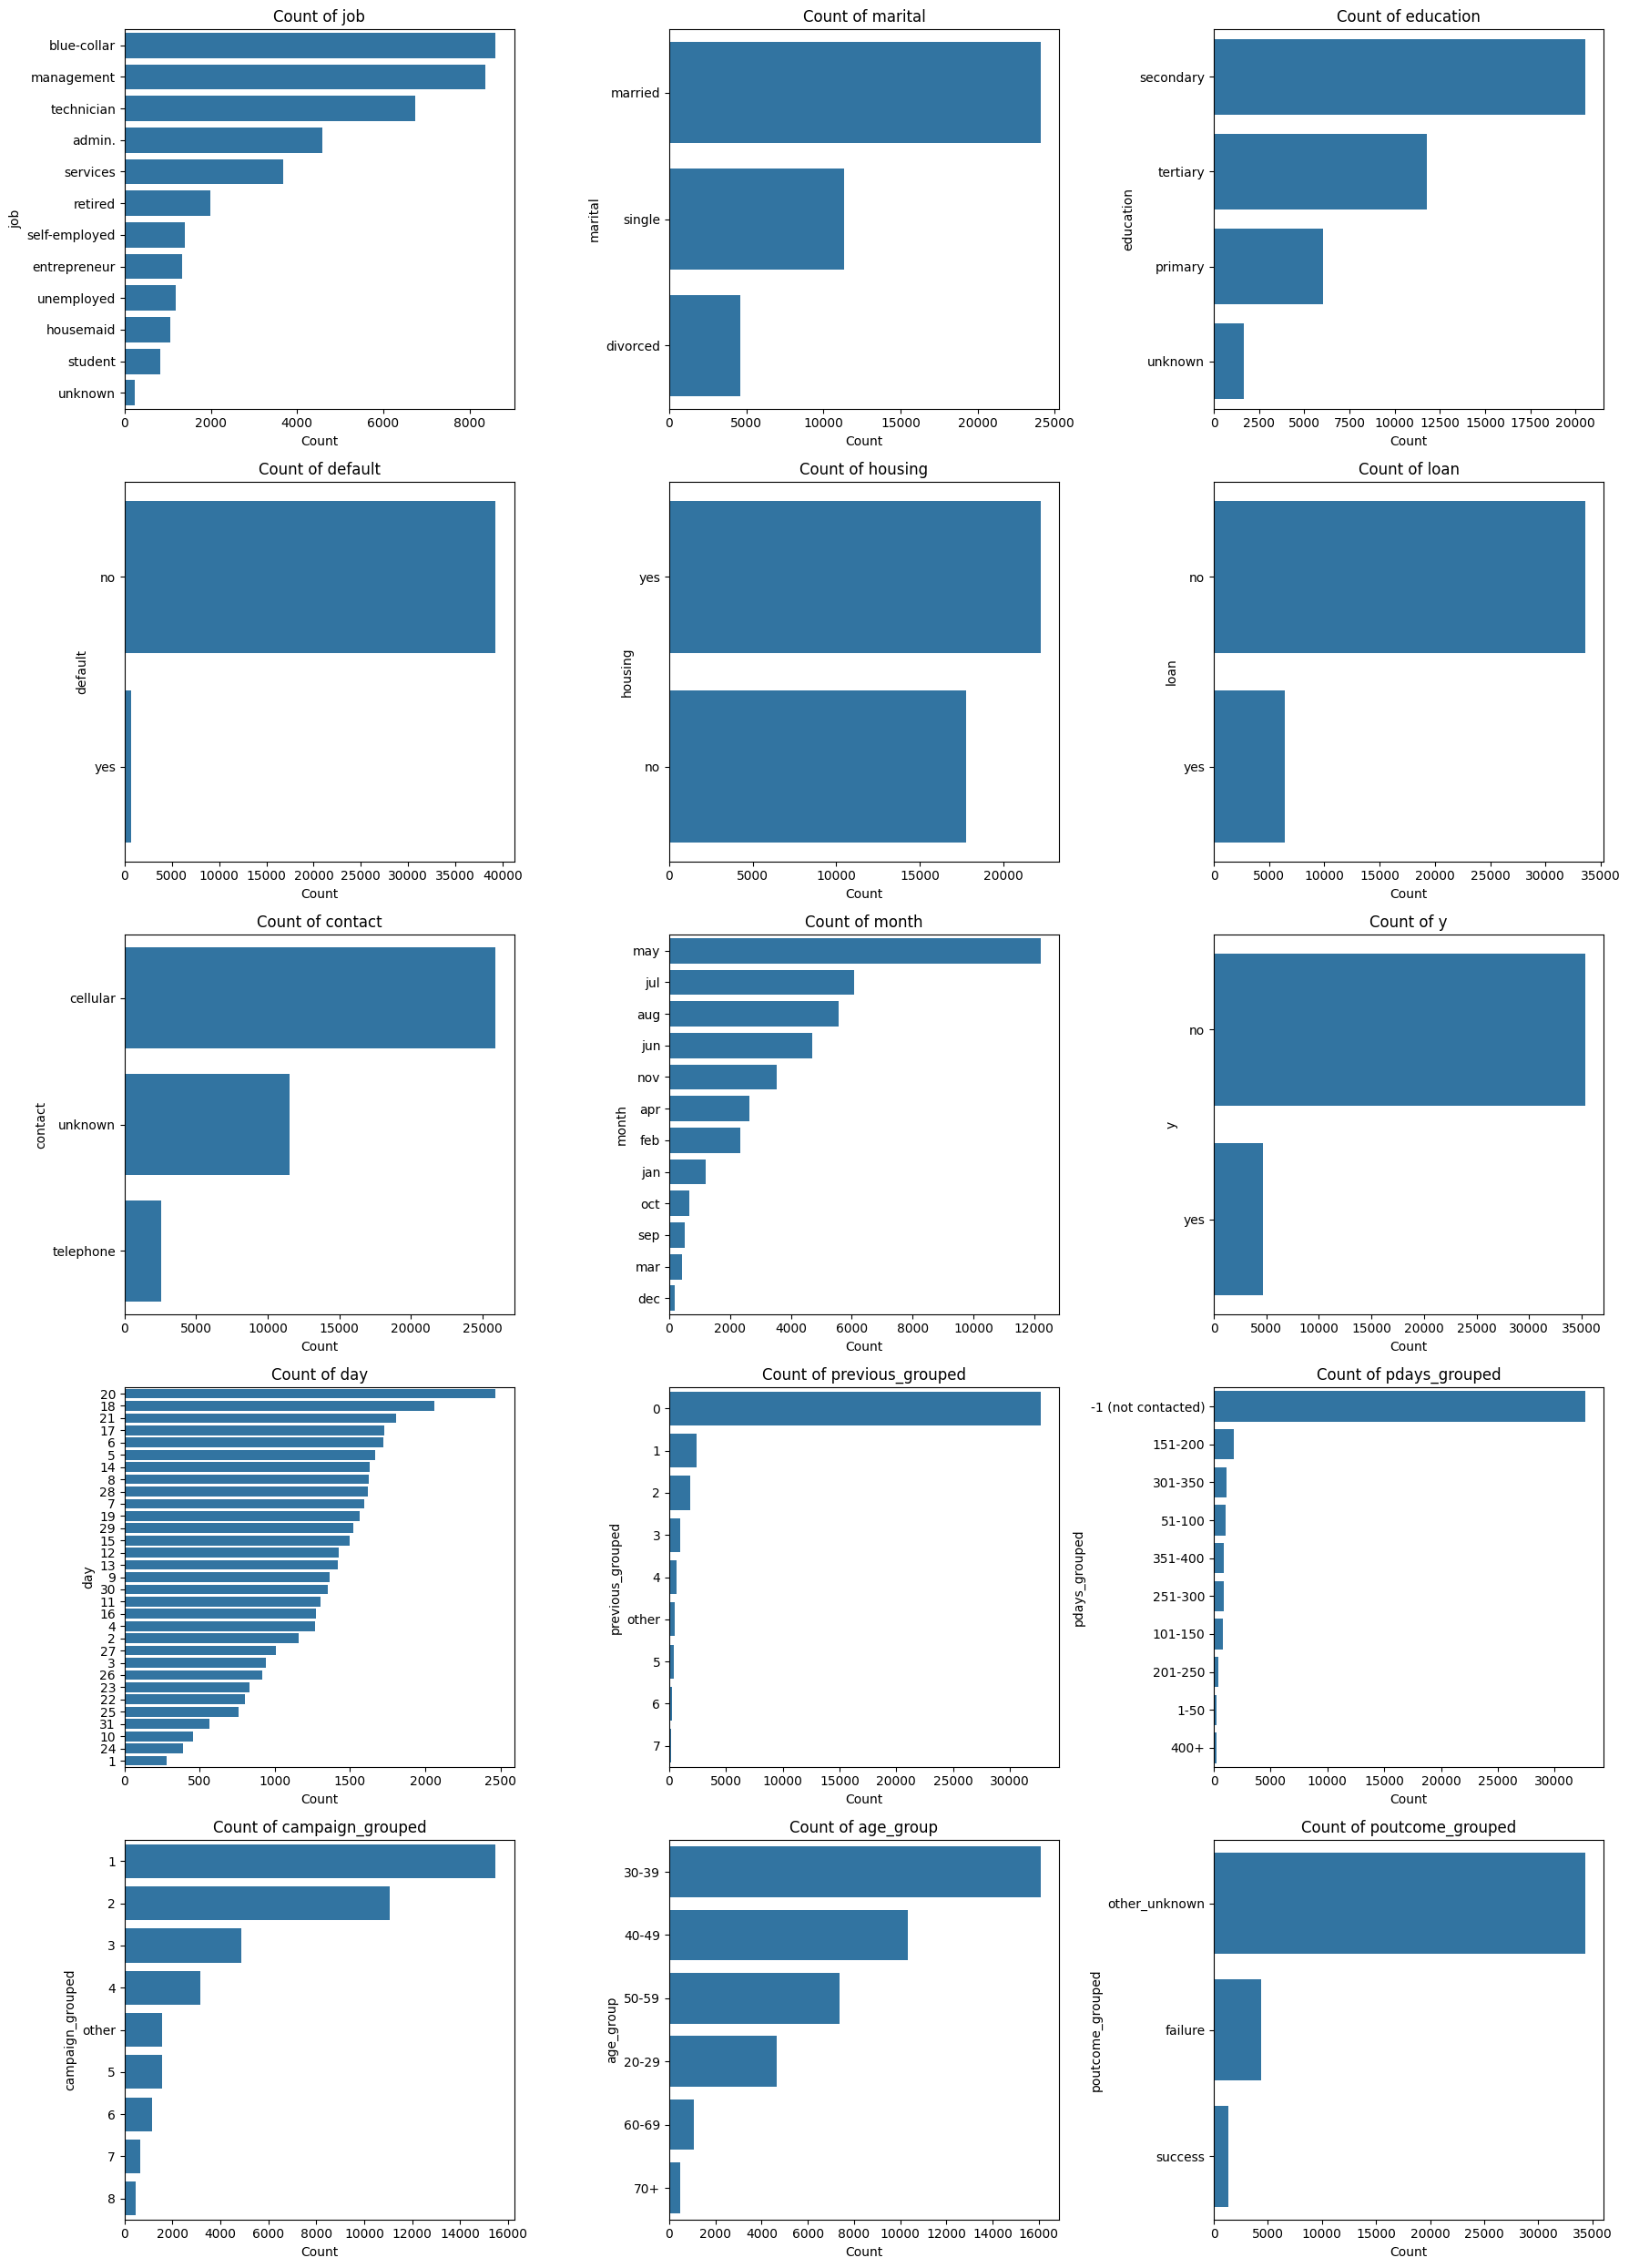

In [6]:
print("Distributions for Categorical Variables")
if categorical_cols:
    n_cat_cols = len(categorical_cols)
    n_cat_rows = (n_cat_cols + 2) // 3
    fig_cat, axes_cat = plt.subplots(n_cat_rows, 3, figsize=(18, 5 * n_cat_rows))
    axes_cat = axes_cat.flatten()

    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, y=col, ax=axes_cat[i], order=df[col].value_counts().index)
        axes_cat[i].set_title(f'Count of {col}')
        axes_cat[i].set_xlabel('Count')
        axes_cat[i].set_ylabel(col)

    for j in range(i + 1, len(axes_cat)):
        fig_cat.delaxes(axes_cat[j])

    plt.tight_layout()
    plt.show()
else:
    print("NA")

Distributions for Numerical Variables


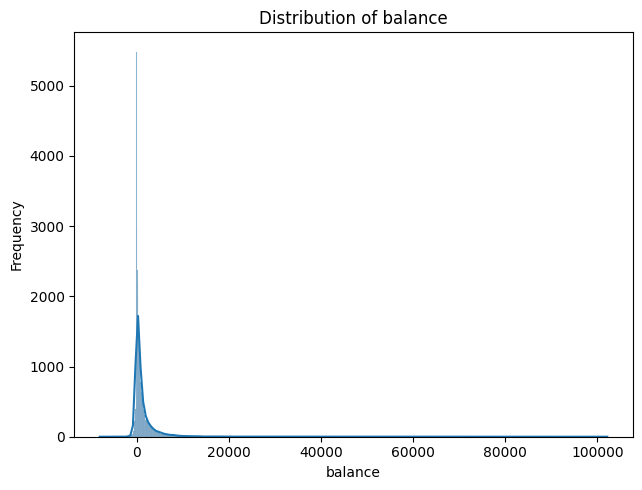

In [7]:
print("Distributions for Numerical Variables")

if numerical_cols:
    n_num_cols = len(numerical_cols)
    n_num_rows = (n_num_cols + 2) // 3
    fig_num, axes_num = plt.subplots(n_num_rows, 3, figsize=(18, 5 * n_num_rows))
    axes_num = axes_num.flatten()

    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes_num[i])
        axes_num[i].set_title(f'Distribution of {col}')
        axes_num[i].set_xlabel(col)
        axes_num[i].set_ylabel('Frequency')

    for j in range(i + 1, len(axes_num)):
        fig_num.delaxes(axes_num[j])

    plt.tight_layout()
    plt.show()
else:
    print("NA")

## Scaling

In [8]:
# target vs features
X = df.drop('y', axis=1)
y = df['y']

categorical_features = [col for col in categorical_cols if col != 'y']
numerical_features = numerical_cols

# One-Hot Encode Categorical Variables ---
X_categorical = pd.get_dummies(X[categorical_features], drop_first=True)
print(f"Shape after OHE: {X_categorical.shape}")

# Winsorization to Numerical Variables
X_numerical_processed = X[numerical_features].copy()
X_numerical_processed['balance'] = winsorize(X_numerical_processed['balance'], limits=[0.01, 0.01])

# RobustScaler to Winsorized Numerical Variables
scaler = RobustScaler()
X_numerical_scaled = scaler.fit_transform(X_numerical_processed)

# Convert back
X_numerical_scaled = pd.DataFrame(X_numerical_scaled, columns=numerical_features, index=X.index)

# Combine Processed Features
df_processed = pd.concat([X_categorical, X_numerical_scaled], axis=1)

display(df_processed.head())
display(y.head())

Shape after OHE: (40000, 65)


,day,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,campaign_grouped_8,campaign_grouped_other,age_group_30-39,age_group_40-49,age_group_50-59,age_group_60-69,age_group_70+,poutcome_grouped_other_unknown,poutcome_grouped_success,balance
0,6,False,False,False,True,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,0.499259
1,17,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,-0.794074
2,23,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,-0.329630
3,18,False,False,False,True,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,1.309630
4,6,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,0.028889


,y
0,no
1,no
2,no
3,no
4,no


## Feature Correlations

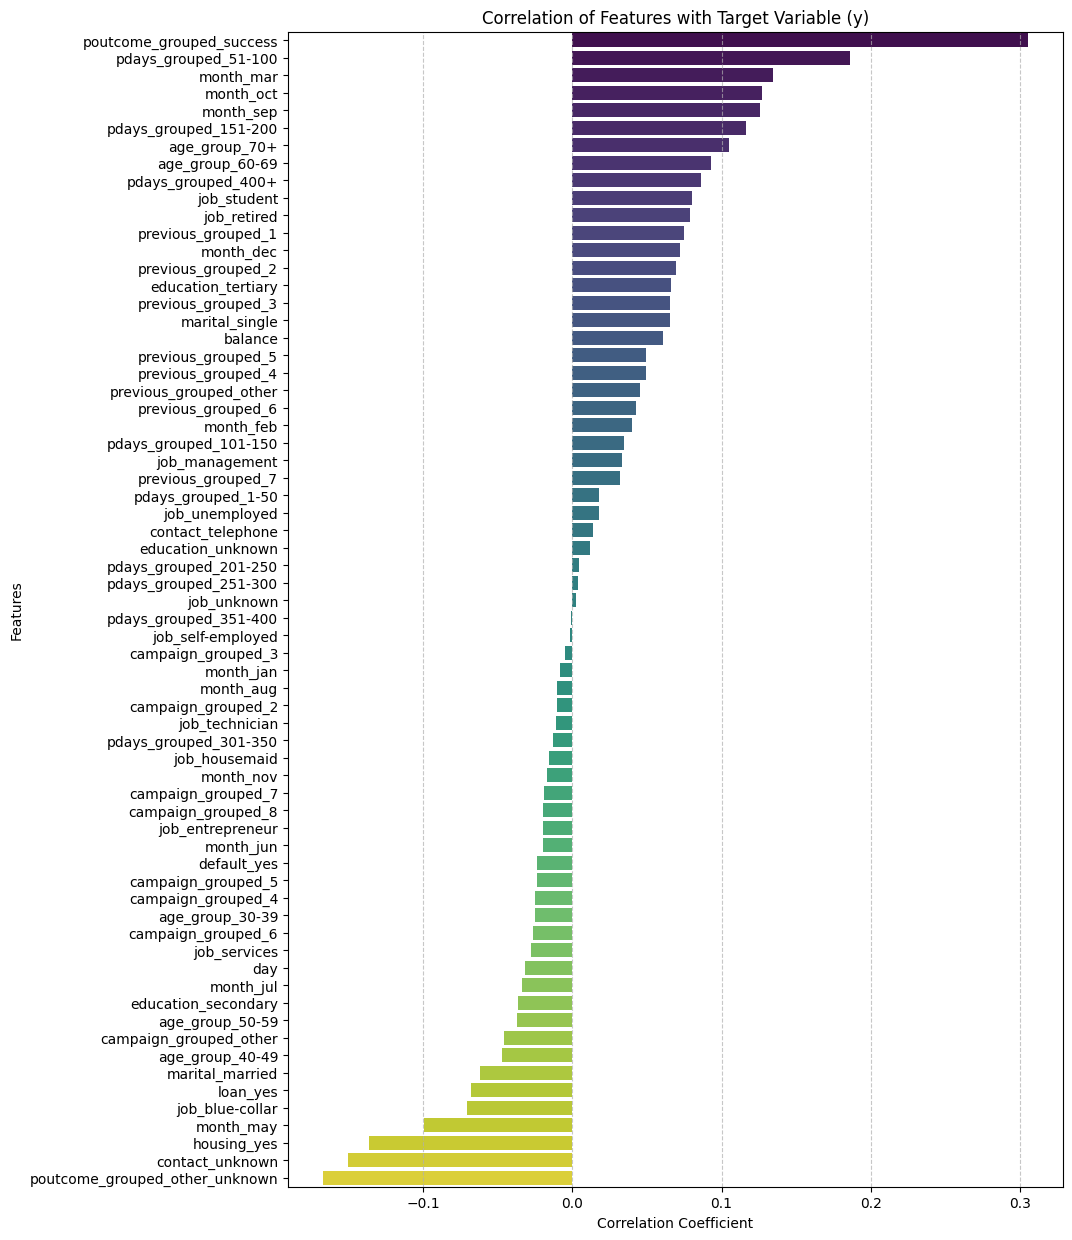

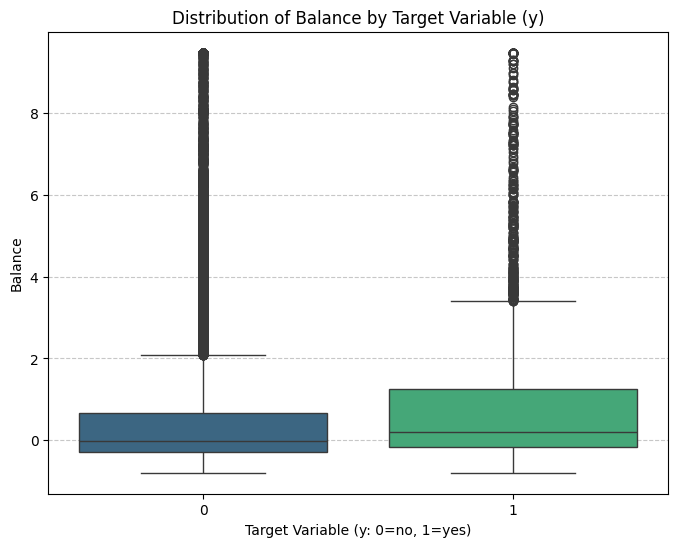

In [9]:
# Map 1 for 'yes', 0 for 'no'
y_numeric = y.map({'yes': 1, 'no': 0})
df_combined = pd.concat([df_processed, y_numeric], axis=1)


correlation_matrix = df_combined.corr()
target_correlations = correlation_matrix['y'].sort_values(ascending=False)
target_correlations = target_correlations.drop('y')

plt.figure(figsize=(10, 15))
sns.barplot(x=target_correlations.values, y=target_correlations.index, palette='viridis', hue=target_correlations.index, legend=False)
plt.title('Correlation of Features with Target Variable (y)')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 'balance' vs 'y'
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_combined['y'], y=df_combined['balance'], palette='viridis', hue=df_combined['y'], legend=False)
plt.title('Distribution of Balance by Target Variable (y)')
plt.xlabel('Target Variable (y: 0=no, 1=yes)')
plt.ylabel('Balance')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Train - Test Split

In [10]:
X_train = df_processed[df['Group'] == 'Training']
X_test = df_processed[df['Group'] == 'Test']
y_train = y[df['Group'] == 'Training']
y_test = y[df['Group'] == 'Test']

# 'yes'/'no' to 1/0
y_train = y_train.map({'yes': 1, 'no': 0})
y_test = y_test.map({'yes': 1, 'no': 0})

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (36000, 66)
Shape of X_test: (4000, 66)
Shape of y_train: (36000,)
Shape of y_test: (4000,)


# Linear Regression

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [12]:
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

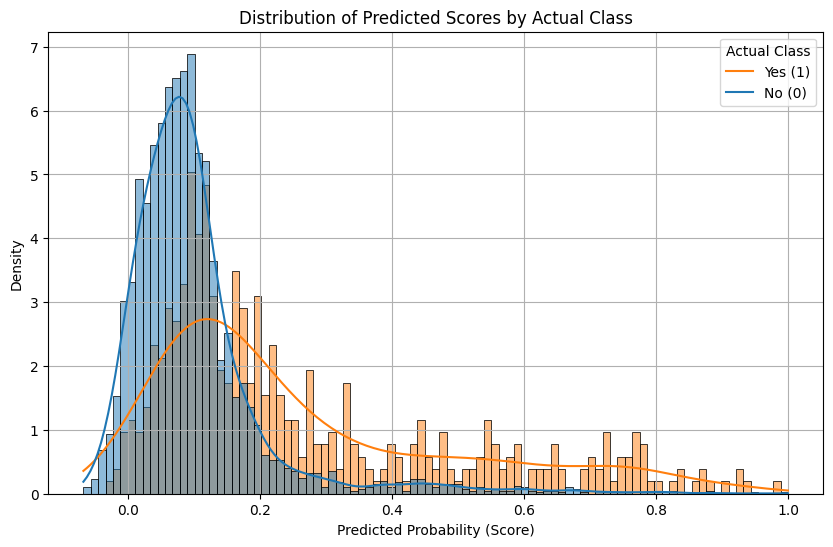

In [13]:
# plotting actual vs. predicted values
plot_df = pd.DataFrame({'Actual': y_test, 'Predicted_Score': y_pred})

plt.figure(figsize=(10, 6))
sns.histplot(data=plot_df, x='Predicted_Score', hue='Actual', kde=True, stat='density', common_norm=False)
plt.title('Distribution of Predicted Scores by Actual Class')
plt.xlabel('Predicted Probability (Score)')
plt.ylabel('Density')
plt.legend(title='Actual Class', labels=['Yes (1)', 'No (0)'])
plt.grid(True)
plt.show()


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      3540
           1       0.57      0.18      0.27       460

    accuracy                           0.89      4000
   macro avg       0.74      0.58      0.60      4000
weighted avg       0.86      0.89      0.86      4000


Confusion Matrix:
[[3479   61]
 [ 379   81]]


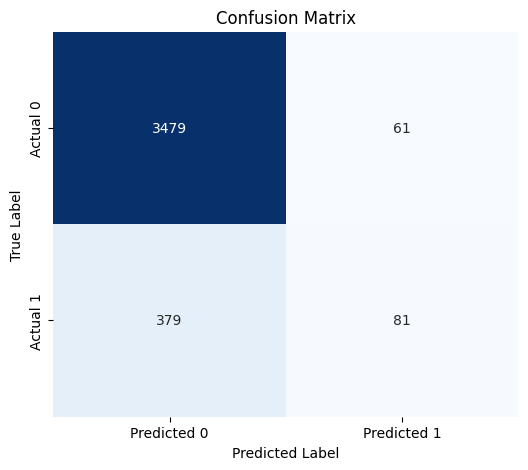

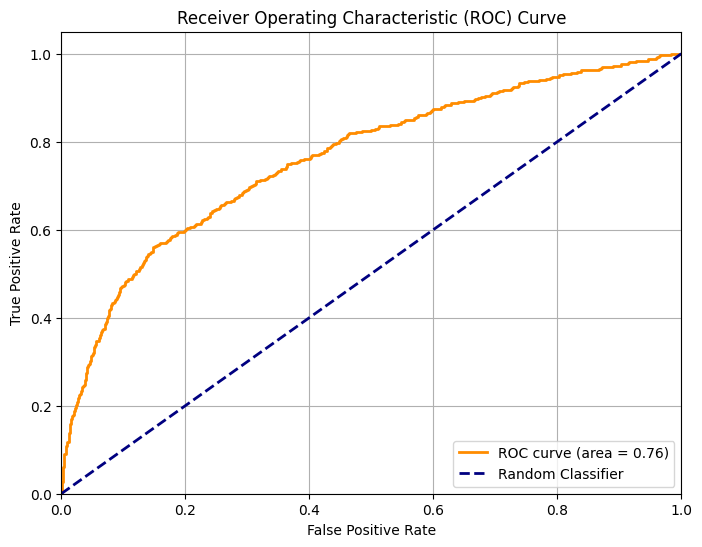


AUC Score: 0.76


In [14]:
# Convert predictions to binary (0 or 1) using a threshold of 0.5
y_pred_binary = (y_pred > 0.5).astype(int)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_binary))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_binary)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# AUC-ROC Chart
# For ROC curve, y_pred (continuous probabilities/scores) are used directly
if len(np.unique(y_test)) == 2 and np.sum(y_test) > 0 and np.sum(y_test == 0) > 0:
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
    print(f"\nAUC Score: {roc_auc:.2f}")
else:
    print("NA")


In [15]:
# Get the coefficients and their corresponding feature names
coefficients_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

coefficients_df['Absolute_Coefficient'] = abs(coefficients_df['Coefficient'])
coefficients_df = coefficients_df.sort_values(by='Absolute_Coefficient', ascending=False)

print("Model Coefficients (sorted by absolute value):")
display(coefficients_df)

Model Coefficients (sorted by absolute value):


,Feature,Coefficient,Absolute_Coefficient
64,poutcome_grouped_success,0.404139,0.404139
48,pdays_grouped_400+,0.256805,0.256805
28,month_mar,0.236904,0.236904
25,month_jan,-0.130004,0.130004
49,pdays_grouped_51-100,0.120647,0.120647
...,...,...,...
65,balance,0.004114,0.004114
7,job_services,-0.002967,0.002967
13,marital_single,-0.001863,0.001863
4,job_management,-0.000980,0.000980


# Logistic Regression

In [16]:
logistic_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
logistic_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [17]:
y_pred_proba_logistic = logistic_model.predict_proba(X_test)[:, 1]
y_pred_proba_logistic_train = logistic_model.predict_proba(X_train)[:, 1]


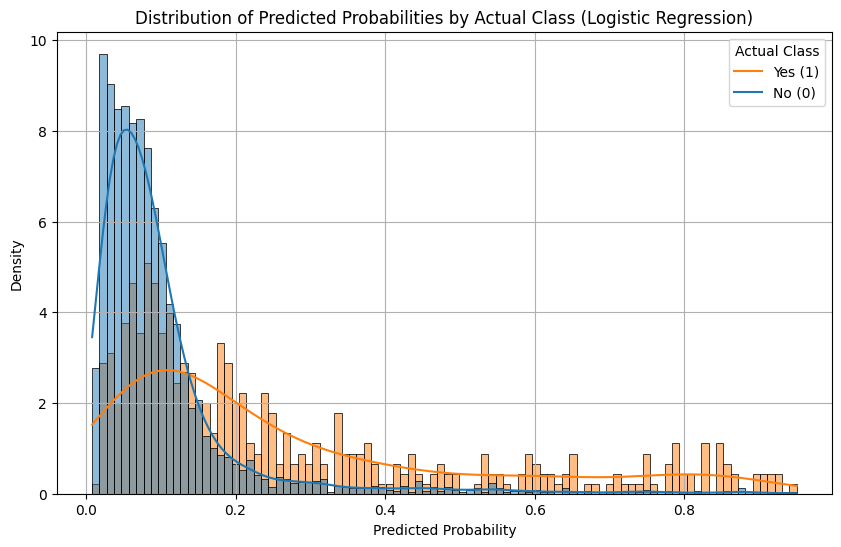

In [18]:
# plotting actual vs. predicted probabilities
plot_df_logistic = pd.DataFrame({'Actual': y_test, 'Predicted_Probability': y_pred_proba_logistic})

plt.figure(figsize=(10, 6))
sns.histplot(data=plot_df_logistic, x='Predicted_Probability', hue='Actual', kde=True, stat='density', common_norm=False)
plt.title('Distribution of Predicted Probabilities by Actual Class (Logistic Regression)')
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.legend(title='Actual Class', labels=['Yes (1)', 'No (0)'])
plt.grid(True)
plt.show()


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      3540
           1       0.53      0.17      0.26       460

    accuracy                           0.89      4000
   macro avg       0.72      0.58      0.60      4000
weighted avg       0.86      0.89      0.86      4000


Logistic Regression Confusion Matrix:
[[3471   69]
 [ 381   79]]


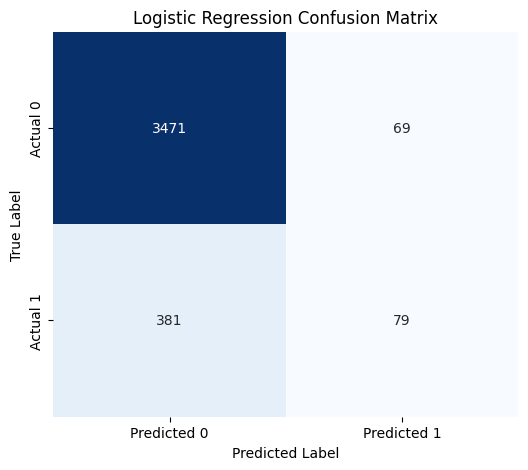

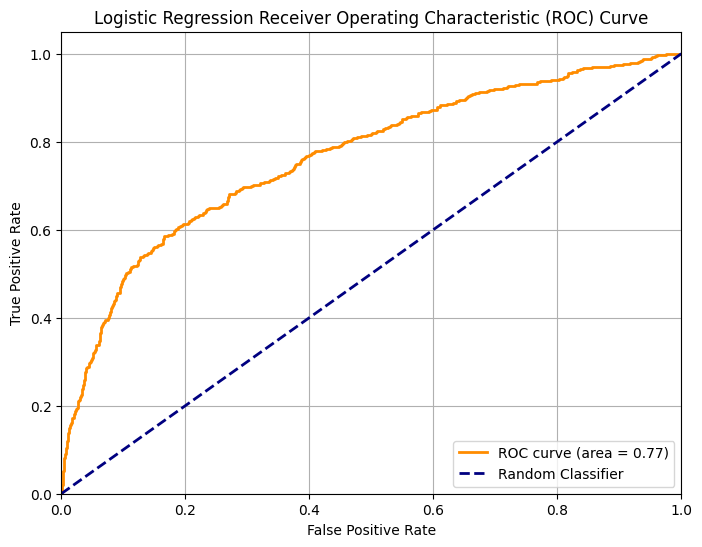


Logistic Regression AUC Score: 0.77


In [19]:
# Convert to binary predictions using a threshold of 0.5
y_pred_binary_logistic = (y_pred_proba_logistic > 0.5).astype(int)

# Classification Report
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_binary_logistic))

# Confusion Matrix
cm_logistic = confusion_matrix(y_test, y_pred_binary_logistic)
print("\nLogistic Regression Confusion Matrix:")
print(cm_logistic)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_logistic, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# AUC-ROC Chart
if len(np.unique(y_test)) == 2 and np.sum(y_test) > 0 and np.sum(y_test == 0) > 0:
    fpr_logistic, tpr_logistic, thresholds_logistic = roc_curve(y_test, y_pred_proba_logistic)
    roc_auc_logistic = auc(fpr_logistic, tpr_logistic)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_logistic, tpr_logistic, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_logistic:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Logistic Regression Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
    print(f"\nLogistic Regression AUC Score: {roc_auc_logistic:.2f}")
else:
    print("NA")

#### Logistic Regression Model Coefficients

In [20]:
coefficients_df_logistic = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': logistic_model.coef_[0]
})

coefficients_df_logistic['Absolute_Coefficient'] = abs(coefficients_df_logistic['Coefficient'])
coefficients_df_logistic = coefficients_df_logistic.sort_values(by='Absolute_Coefficient', ascending=False)

print("Logistic Regression Model Coefficients (sorted by absolute value):")
display(coefficients_df_logistic)

Logistic Regression Model Coefficients (sorted by absolute value):


,Feature,Coefficient,Absolute_Coefficient
64,poutcome_grouped_success,2.014696,2.014696
48,pdays_grouped_400+,1.567993,1.567993
21,contact_unknown,-1.331185,1.331185
25,month_jan,-1.145660,1.145660
28,month_mar,1.023851,1.023851
...,...,...,...
65,balance,0.041390,0.041390
4,job_management,-0.026703,0.026703
33,previous_grouped_1,-0.002773,0.002773
0,day,0.001846,0.001846


## Logistic Regression with SMOTE

In [21]:
print("Original training set shape:", X_train.shape, y_train.shape)
print("Original 'yes' class count:", y_train.value_counts()[1])
print("Original 'no' class count:", y_train.value_counts()[0])

# Apply SMOTE to the training data
sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

print("\nTraining set shape after SMOTE:", X_train_smote.shape, y_train_smote.shape)
print(" 'yes' class count after SMOTE:", y_train_smote.value_counts()[1])
print(" 'no' class count after SMOTE:", y_train_smote.value_counts()[0])

Original training set shape: (36000, 66) (36000,)
Original 'yes' class count: 4210
Original 'no' class count: 31790

Training set shape after SMOTE: (63580, 66) (63580,)
 'yes' class count after SMOTE: 31790
 'no' class count after SMOTE: 31790


In [22]:
logistic_model_smote = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
logistic_model_smote.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [23]:
y_pred_proba_logistic_smote = logistic_model_smote.predict_proba(X_test)[:, 1]
y_pred_proba_logistic_smote_train = logistic_model_smote.predict_proba(X_train_smote)[:, 1]

In [24]:
coefficients_df_logistic_smote = pd.DataFrame({
    'Feature': X_train_smote.columns,
    'Coefficient': logistic_model_smote.coef_[0]
})

coefficients_df_logistic_smote['Absolute_Coefficient'] = abs(coefficients_df_logistic_smote['Coefficient'])
coefficients_df_logistic_smote = coefficients_df_logistic_smote.sort_values(by='Absolute_Coefficient', ascending=False)

print("Logistic Regression (SMOTE) Model Coefficients (sorted by absolute value):")

Logistic Regression (SMOTE) Model Coefficients (sorted by absolute value):


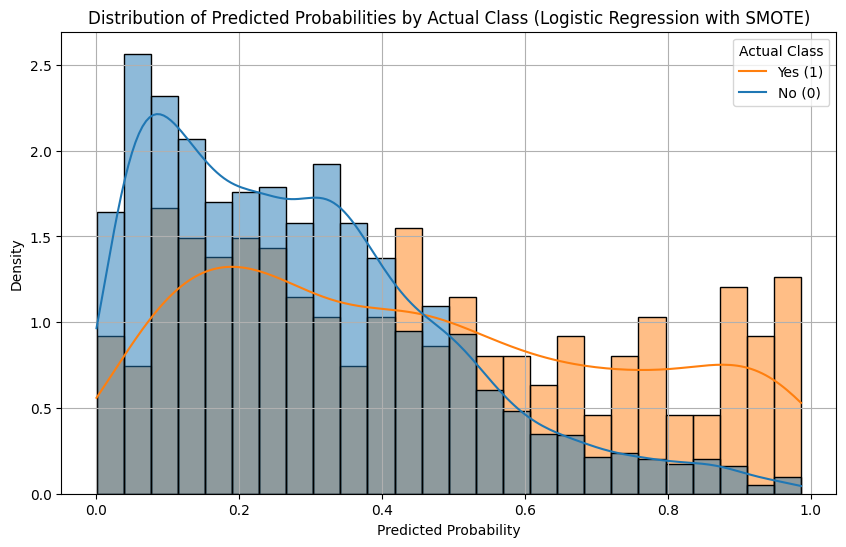

In [25]:
# plotting actual vs. predicted probabilities
plot_df_logistic_smote = pd.DataFrame({'Actual': y_test, 'Predicted_Probability': y_pred_proba_logistic_smote})

plt.figure(figsize=(10, 6))
sns.histplot(data=plot_df_logistic_smote, x='Predicted_Probability', hue='Actual', kde=True, stat='density', common_norm=False)
plt.title('Distribution of Predicted Probabilities by Actual Class (Logistic Regression with SMOTE)')
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.legend(title='Actual Class', labels=['Yes (1)', 'No (0)'])
plt.grid(True)
plt.show()


Logistic Regression (SMOTE) Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.85      0.88      3540
           1       0.26      0.40      0.32       460

    accuracy                           0.80      4000
   macro avg       0.59      0.63      0.60      4000
weighted avg       0.84      0.80      0.82      4000


Logistic Regression (SMOTE) Confusion Matrix:
[[3012  528]
 [ 275  185]]


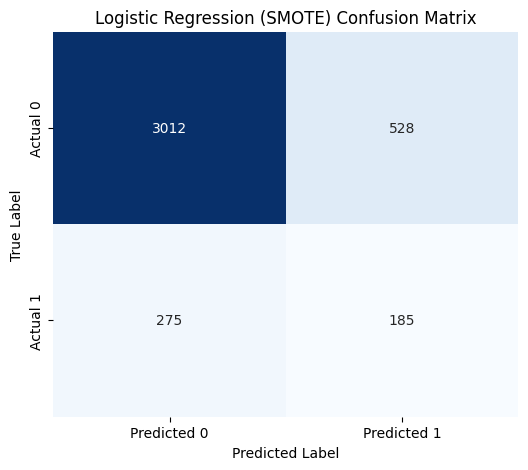

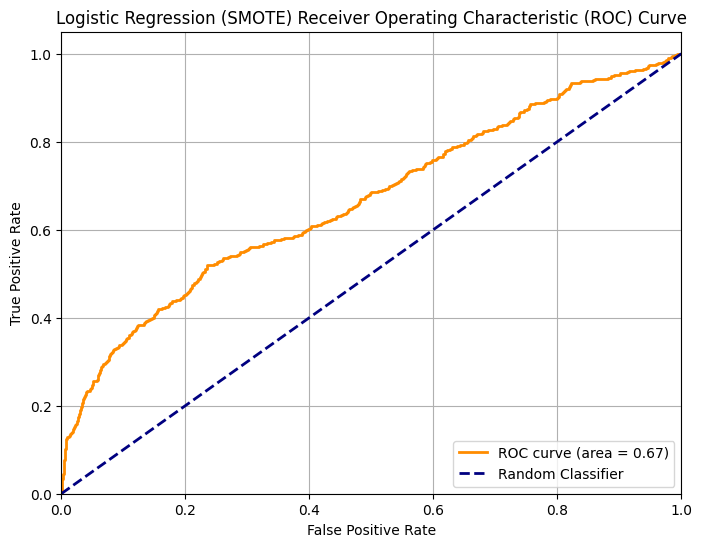


Logistic Regression (SMOTE) AUC Score: 0.67


In [26]:
# Convert to binary predictions using a threshold of 0.5
y_pred_binary_logistic_smote = (y_pred_proba_logistic_smote > 0.5).astype(int)

#Classification Report
print("\nLogistic Regression (SMOTE) Classification Report:")
print(classification_report(y_test, y_pred_binary_logistic_smote))

# Confusion Matrix
cm_logistic_smote = confusion_matrix(y_test, y_pred_binary_logistic_smote)
print("\nLogistic Regression (SMOTE) Confusion Matrix:")
print(cm_logistic_smote)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_logistic_smote, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Logistic Regression (SMOTE) Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# AUC-ROC Chart
if len(np.unique(y_test)) == 2 and np.sum(y_test) > 0 and np.sum(y_test == 0) > 0:
    fpr_logistic_smote, tpr_logistic_smote, thresholds_logistic_smote = roc_curve(y_test, y_pred_proba_logistic_smote)
    roc_auc_logistic_smote = auc(fpr_logistic_smote, tpr_logistic_smote)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_logistic_smote, tpr_logistic_smote, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_logistic_smote:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Logistic Regression (SMOTE) Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
    print(f"\nLogistic Regression (SMOTE) AUC Score: {roc_auc_logistic_smote:.2f}")
else:
    print("NA")

## Logistic Regression with class_weight='balanced'

In [27]:
logistic_model_balanced = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000, class_weight='balanced')
logistic_model_balanced.fit(X_train, y_train)

y_pred_proba_logistic_balanced = logistic_model_balanced.predict_proba(X_test)[:, 1]
y_pred_proba_logistic_balanced_train = logistic_model_balanced.predict_proba(X_train)[:, 1]

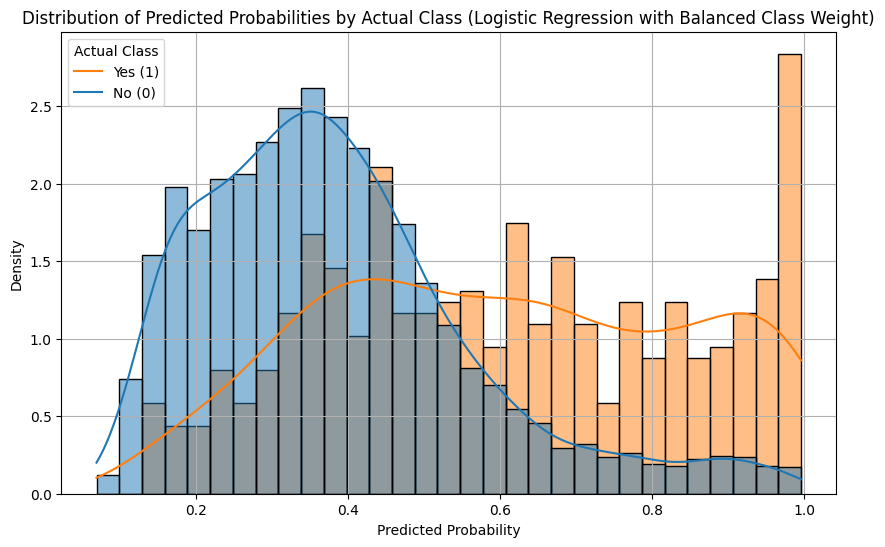

In [28]:
plot_df_logistic_balanced = pd.DataFrame({'Actual': y_test, 'Predicted_Probability': y_pred_proba_logistic_balanced})

plt.figure(figsize=(10, 6))
sns.histplot(data=plot_df_logistic_balanced, x='Predicted_Probability', hue='Actual', kde=True, stat='density', common_norm=False)
plt.title('Distribution of Predicted Probabilities by Actual Class (Logistic Regression with Balanced Class Weight)')
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.legend(title='Actual Class', labels=['Yes (1)', 'No (0)'])
plt.grid(True)
plt.show()


Logistic Regression (Balanced Class Weight) Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.79      0.86      3540
           1       0.28      0.62      0.39       460

    accuracy                           0.78      4000
   macro avg       0.61      0.71      0.63      4000
weighted avg       0.87      0.78      0.81      4000


Logistic Regression (Balanced Class Weight) Confusion Matrix:
[[2814  726]
 [ 173  287]]


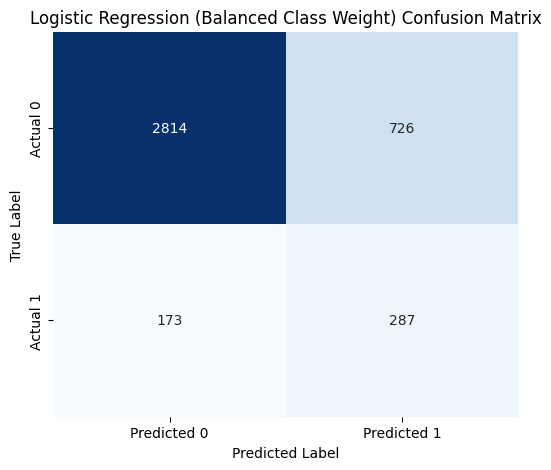

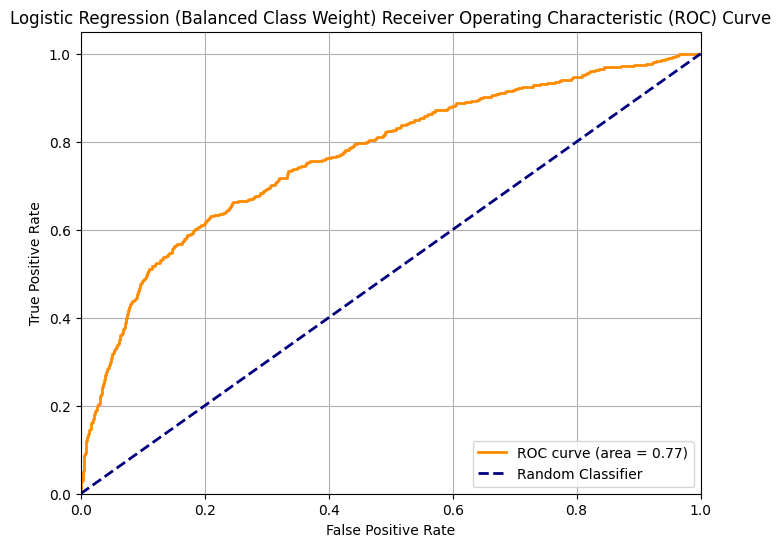


Logistic Regression (Balanced Class Weight) AUC Score: 0.77


In [37]:
# Convert probabilities to binary predictions using a threshold of 0.5
y_pred_binary_logistic_balanced = (y_pred_proba_logistic_balanced > 0.5).astype(int)

# Classification Report
print("\nLogistic Regression (Balanced Class Weight) Classification Report:")
print(classification_report(y_test, y_pred_binary_logistic_balanced))

#Confusion Matrix
cm_logistic_balanced = confusion_matrix(y_test, y_pred_binary_logistic_balanced)
print("\nLogistic Regression (Balanced Class Weight) Confusion Matrix:")
print(cm_logistic_balanced)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_logistic_balanced, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Logistic Regression (Balanced Class Weight) Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# AUC-ROC Chart
if len(np.unique(y_test)) == 2 and np.sum(y_test) > 0 and np.sum(y_test == 0) > 0:
    fpr_logistic_balanced, tpr_logistic_balanced, thresholds_logistic_balanced = roc_curve(y_test, y_pred_proba_logistic_balanced)
    roc_auc_logistic_balanced = auc(fpr_logistic_balanced, tpr_logistic_balanced)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_logistic_balanced, tpr_logistic_balanced, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_logistic_balanced:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Logistic Regression (Balanced Class Weight) Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
    print(f"\nLogistic Regression (Balanced Class Weight) AUC Score: {roc_auc_logistic_balanced:.2f}")
else:
    print("NA")

In [30]:
coefficients_df_logistic_balanced = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': logistic_model_balanced.coef_[0]
})

coefficients_df_logistic_balanced['Absolute_Coefficient'] = abs(coefficients_df_logistic_balanced['Coefficient'])
coefficients_df_logistic_balanced = coefficients_df_logistic_balanced.sort_values(by='Absolute_Coefficient', ascending=False)

print("\nLogistic Regression (Balanced Class Weight) Model Coefficients (sorted by absolute value):")
display(coefficients_df_logistic_balanced)


Logistic Regression (Balanced Class Weight) Model Coefficients (sorted by absolute value):


,Feature,Coefficient,Absolute_Coefficient
64,poutcome_grouped_success,2.084236,2.084236
48,pdays_grouped_400+,1.851628,1.851628
28,month_mar,1.233507,1.233507
21,contact_unknown,-1.232491,1.232491
25,month_jan,-1.077712,1.077712
...,...,...,...
5,job_retired,0.021641,0.021641
27,month_jun,0.020733,0.020733
33,previous_grouped_1,-0.006642,0.006642
41,pdays_grouped_1-50,-0.002530,0.002530


# Model Performance Comparison: Specificity and Sensitivity

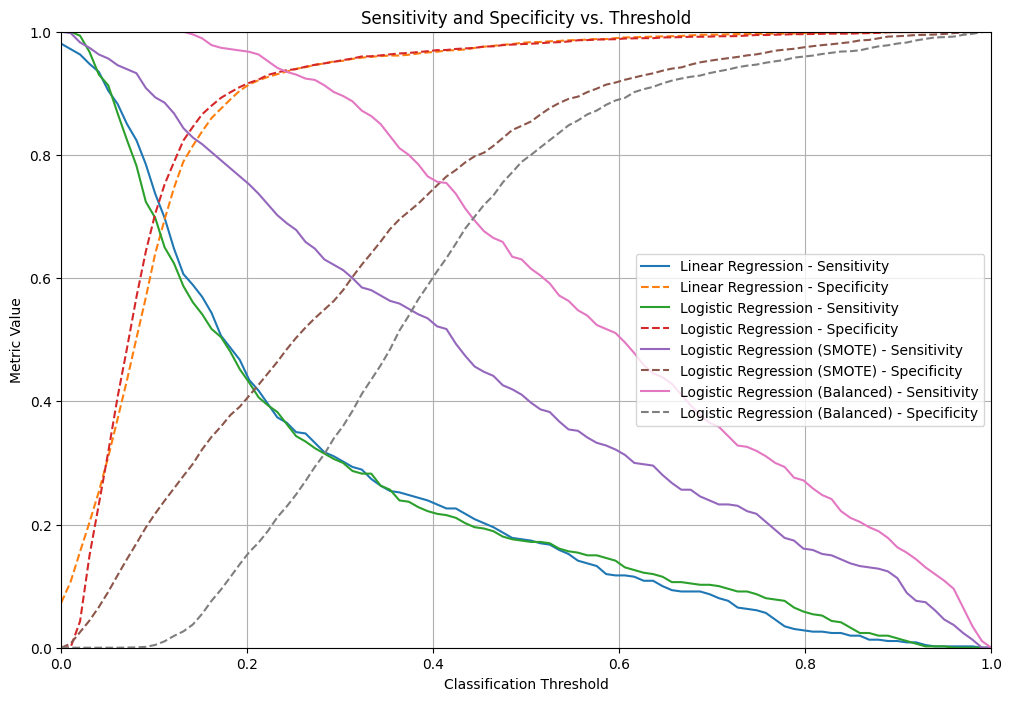

In [35]:
def plot_sensitivity_specificity_vs_threshold(y_true, y_probas, model_names, title="Sensitivity and Specificity vs. Threshold"):
    plt.figure(figsize=(12, 8))

    thresholds = np.linspace(0, 1, 100)

    for i, y_proba in enumerate(y_probas):
        sensitivities = []
        specificities = []

        for t in thresholds:
            y_pred_binary = (y_proba > t).astype(int)

            # confusion matrix
            cm = confusion_matrix(y_true, y_pred_binary)
            tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)

            # Sensitivity (Recall) = TP / (TP + FN)
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            sensitivities.append(sensitivity)

            # Specificity = TN / (TN + FP)
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            specificities.append(specificity)

        plt.plot(thresholds, sensitivities, label=f'{model_names[i]} - Sensitivity', linestyle='-')
        plt.plot(thresholds, specificities, label=f'{model_names[i]} - Specificity', linestyle='--')

    plt.title(title)
    plt.xlabel('Classification Threshold')
    plt.ylabel('Metric Value')
    plt.legend()
    plt.grid(True)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.show()


y_probas_list = [
    y_pred, # Linear Regression uses raw predictions, not probabilities
    y_pred_proba_logistic,
    y_pred_proba_logistic_smote,
    y_pred_proba_logistic_balanced
]

model_names_list = [
    'Linear Regression',
    'Logistic Regression',
    'Logistic Regression (SMOTE)',
    'Logistic Regression (Balanced)'
]

plot_sensitivity_specificity_vs_threshold(y_test, y_probas_list, model_names_list)


# More Model Comparisons

In [33]:
print("\n--- Linear Regression Model Coefficients ---")
display(coefficients_df.head(20))

print("\n--- Logistic Regression Model Coefficients ---")
display(coefficients_df_logistic.head(20))

print("\n--- Logistic Regression (SMOTE) Model Coefficients ---")
display(coefficients_df_logistic_smote.head(20))

print("\n--- Logistic Regression (Balanced Class Weight) Model Coefficients ---")
display(coefficients_df_logistic_balanced.head(20))


--- Linear Regression Model Coefficients ---


,Feature,Coefficient,Absolute_Coefficient
64,poutcome_grouped_success,0.404139,0.404139
48,pdays_grouped_400+,0.256805,0.256805
28,month_mar,0.236904,0.236904
25,month_jan,-0.130004,0.130004
49,pdays_grouped_51-100,0.120647,0.120647
23,month_dec,0.114432,0.114432
30,month_nov,-0.111522,0.111522
22,month_aug,-0.109834,0.109834
31,month_oct,0.104969,0.104969
32,month_sep,0.104629,0.104629



--- Logistic Regression Model Coefficients ---


,Feature,Coefficient,Absolute_Coefficient
64,poutcome_grouped_success,2.014696,2.014696
48,pdays_grouped_400+,1.567993,1.567993
21,contact_unknown,-1.331185,1.331185
25,month_jan,-1.145660,1.145660
28,month_mar,1.023851,1.023851
30,month_nov,-0.955084,0.955084
22,month_aug,-0.906010,0.906010
57,campaign_grouped_other,-0.807487,0.807487
26,month_jul,-0.802208,0.802208
54,campaign_grouped_6,-0.708111,0.708111



--- Logistic Regression (SMOTE) Model Coefficients ---


,Feature,Coefficient,Absolute_Coefficient
28,month_mar,3.065641,3.065641
8,job_student,3.029435,3.029435
64,poutcome_grouped_success,2.854167,2.854167
31,month_oct,2.792943,2.792943
62,age_group_70+,2.745246,2.745246
63,poutcome_grouped_other_unknown,2.495224,2.495224
32,month_sep,2.459638,2.459638
1,job_blue-collar,2.214928,2.214928
5,job_retired,2.179901,2.179901
61,age_group_60-69,2.163188,2.163188



--- Logistic Regression (Balanced Class Weight) Model Coefficients ---


,Feature,Coefficient,Absolute_Coefficient
64,poutcome_grouped_success,2.084236,2.084236
48,pdays_grouped_400+,1.851628,1.851628
28,month_mar,1.233507,1.233507
21,contact_unknown,-1.232491,1.232491
25,month_jan,-1.077712,1.077712
30,month_nov,-0.890669,0.890669
22,month_aug,-0.869909,0.869909
49,pdays_grouped_51-100,0.830771,0.830771
26,month_jul,-0.730102,0.730102
31,month_oct,0.717620,0.717620
